# ResNet20 / CIFAR-100 Compression — Quickstart

This is a short, Colab-friendly walkthrough of the `resnet_compression` package: structural
filter pruning, ensemble knowledge distillation (KD), and INT8/INT4 quantization-aware
training (QAT) for a ResNet20 classifier on CIFAR-100.

It is deliberately fast (a couple of minutes, CPU is fine) so you can see every stage run
end to end. It uses tiny synthetic data and 1-2 epochs everywhere, so **the accuracies
below are meaningless** — this notebook is about the mechanics, not the results.

For an actual full experiment (hours, GPU recommended), use the `resnet-compress`
command-line tool described in the main [README](../README.md) instead of a notebook:
long-running training is easier to resume, log and monitor from the command line.


In [1]:
# If you're running this in Colab, uncomment the next two lines first.
# !git clone https://github.com/<your-username>/<your-repo>.git
# %cd <your-repo>

%pip install -e .. -q

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

## 1. Models

`resnet_compression.models` builds the CIFAR-style ResNet20/32/56 and WideResNet
architectures used throughout the pipeline (ResNet20 as the student/baseline; ResNet32,
ResNet56 and WideResNet-28-10 as the teacher ensemble).


In [3]:
import torch

from resnet_compression.models import resnet20
from resnet_compression.utils import count_conv_filters, count_parameters, get_model_size_mb

model = resnet20(num_classes=100)
x = torch.randn(4, 3, 32, 32)
logits = model(x)

print("Output shape:", tuple(logits.shape))
print(f"Parameters:   {count_parameters(model):,}")
print(f"Conv filters: {count_conv_filters(model)}")
print(f"Size:         {get_model_size_mb(model):.3f} MB")

Output shape: (4, 100)
Parameters:   278,324
Conv filters: 784
Size:         1.068 MB


## 2. Structural filter pruning

`prune_filters` removes the lowest-L1-norm filters of every residual block's two 3x3
convolutions and rebuilds a physically smaller network, transferring the surviving
weights (including batch-norm statistics and the matching input channels of downstream
layers). The result is *not* accuracy-preserving on its own — that's what the
fine-tuning (with or without KD) in Scenarios A/B is for.


In [4]:
from resnet_compression.pruning import prune_filters

pruned_model, num_removed = prune_filters(model, prune_percentage=0.2)

print(f"Filters removed:        {num_removed}")
print(f"Parameters before:      {count_parameters(model):,}")
print(f"Parameters after:       {count_parameters(pruned_model):,}")
print(f"Size before -> after:   {get_model_size_mb(model):.3f} MB -> {get_model_size_mb(pruned_model):.3f} MB")

# The network is still runnable immediately after pruning (just not yet fine-tuned).
pruned_model.eval()
with torch.no_grad():
    out = pruned_model(x)
print("Pruned output shape:", tuple(out.shape))

Filters removed:        126
Parameters before:      278,324
Parameters after:       185,723
Size before -> after:   1.068 MB -> 0.714 MB
Pruned output shape: (4, 100)


## 3. Quantization-aware training (INT8 vs INT4)

`prepare_qat_model` wraps a *copy* of the model with quant/dequant stubs and inserts
fake-quantization modules, so that fine-tuning happens with realistic quantization noise
before the model is actually converted to a quantized `nn.Module`.

Preparing INT8 and INT4 independently (each from its own deep copy) is the fix for a bug
found in the original notebook — see [`NOTES.md`](../NOTES.md#bug-1-the-notebooks-int4-qat-model-was-mostly-still-int8)
for the full story. The cell below shows the two are indeed independent: INT8's internal
convolutions use an 8-bit range and INT4's use a genuine 4-bit range.


In [5]:
from resnet_compression.quantization import prepare_qat_model

qat_int8 = prepare_qat_model(pruned_model, qconfig_type="int8", backend="fbgemm")
qat_int4 = prepare_qat_model(pruned_model, qconfig_type="int4")

conv_int8 = qat_int8.layer2[0].conv1.weight_fake_quant
conv_int4 = qat_int4.layer2[0].conv1.weight_fake_quant

print(f"INT8 internal conv weight range: [{conv_int8.quant_min}, {conv_int8.quant_max}]")
print(f"INT4 internal conv weight range: [{conv_int4.quant_min}, {conv_int4.quant_max}]")
assert (conv_int8.quant_min, conv_int8.quant_max) == (-128, 127)
assert (conv_int4.quant_min, conv_int4.quant_max) == (-8, 7)
print("Independent INT8/INT4 preparation confirmed.")

INT8 internal conv weight range: [-128, 127]
INT4 internal conv weight range: [-8, 7]
Independent INT8/INT4 preparation confirmed.


## 4. The full pipeline, at smoke-test scale

`resnet_compression.cli.run` drives the complete pipeline: baseline -> teachers ->
Scenario A (pruning + KD) -> Scenario B (pruning, no KD) -> best-model selection ->
Scenario C (QAT + KD) -> Scenario D (QAT, no KD) -> plots + summary report.

`Config().apply_smoke_test()` shrinks every schedule to 1-2 epochs/iterations on tiny
synthetic data (no download), so the whole thing finishes in about a minute. Every stage
is resumable: re-running the same config loads cached results instead of retraining.


In [6]:
from pathlib import Path

from resnet_compression.cli import run
from resnet_compression.config import Config

cfg = Config(output_dir="./demo_run", data_dir="./demo_data").apply_smoke_test()
_ = run(cfg)  # returns an exit code (0 = success); assigned to `_` so it isn't echoed below

04:06:41 | INFO    | ================================================================================


04:06:41 | INFO    | ResNet20 / CIFAR-100 adaptive filter pruning pipeline


04:06:41 | INFO    | ================================================================================


04:06:41 | INFO    | Device: cpu


04:06:41 | INFO    | Output directory: demo_run


...

04:07:27 | INFO    | Saved: complete_results_summary.csv


04:07:27 | INFO    | 
COMPLETE RESULTS SUMMARY
   Model     Scenario Pruning Quantization Accuracy (%) Acc Drop (%)  Params Size (MB) Compression
Baseline            -       -         FP32         0.78         0.00 278,324     1.068       1.00x
    A-5%       A (KD)      5%         FP32         0.00         0.78 235,692     0.905       1.18x
    B-5%    B (No-KD)      5%         FP32         0.00         0.78 235,692     0.905       1.18x
   A-10%       A (KD)     10%         FP32         1.56        -0.78 195,540     0.751       1.42x
   B-10%    B (No-KD)     10%         FP32         0.78         0.00 195,540     0.751       1.42x
  C-INT8   C (QAT+KD)     10%         INT8         0.00         0.78 191,620     0.285       3.74x
  C-INT4   C (QAT+KD)     10%         INT4         1.56        -0.78 191,620     0.264       4.04x
  D-INT8 D (QAT-NoKD)     10%         INT8         0.00         0.78 191,620     0.285       3.74x
  D-INT4 D (QAT-NoKD)     10%         INT4         0.78       

04:07:27 | INFO    | ================================================================================


04:07:27 | INFO    | Pipeline finished


04:07:27 | INFO    | ================================================================================


### Results

In [7]:
import pandas as pd

pd.read_csv(Path(cfg.output_dir) / "complete_results_summary.csv")

,Model,Scenario,Pruning,Quantization,Accuracy (%),Acc Drop (%),Params,Size (MB),Compression
0,Baseline,-,-,FP32,0.78,0.00,"278,324",1.068,1.00x
1,A-5%,A (KD),5%,FP32,0.00,0.78,"235,692",0.905,1.18x
2,B-5%,B (No-KD),5%,FP32,0.00,0.78,"235,692",0.905,1.18x
3,A-10%,A (KD),10%,FP32,1.56,-0.78,"195,540",0.751,1.42x
4,B-10%,B (No-KD),10%,FP32,0.78,0.00,"195,540",0.751,1.42x
5,C-INT8,C (QAT+KD),10%,INT8,0.00,0.78,"191,620",0.285,3.74x
6,C-INT4,C (QAT+KD),10%,INT4,1.56,-0.78,"191,620",0.264,4.04x
7,D-INT8,D (QAT-NoKD),10%,INT8,0.00,0.78,"191,620",0.285,3.74x
8,D-INT4,D (QAT-NoKD),10%,INT4,0.78,0.00,"191,620",0.264,4.04x


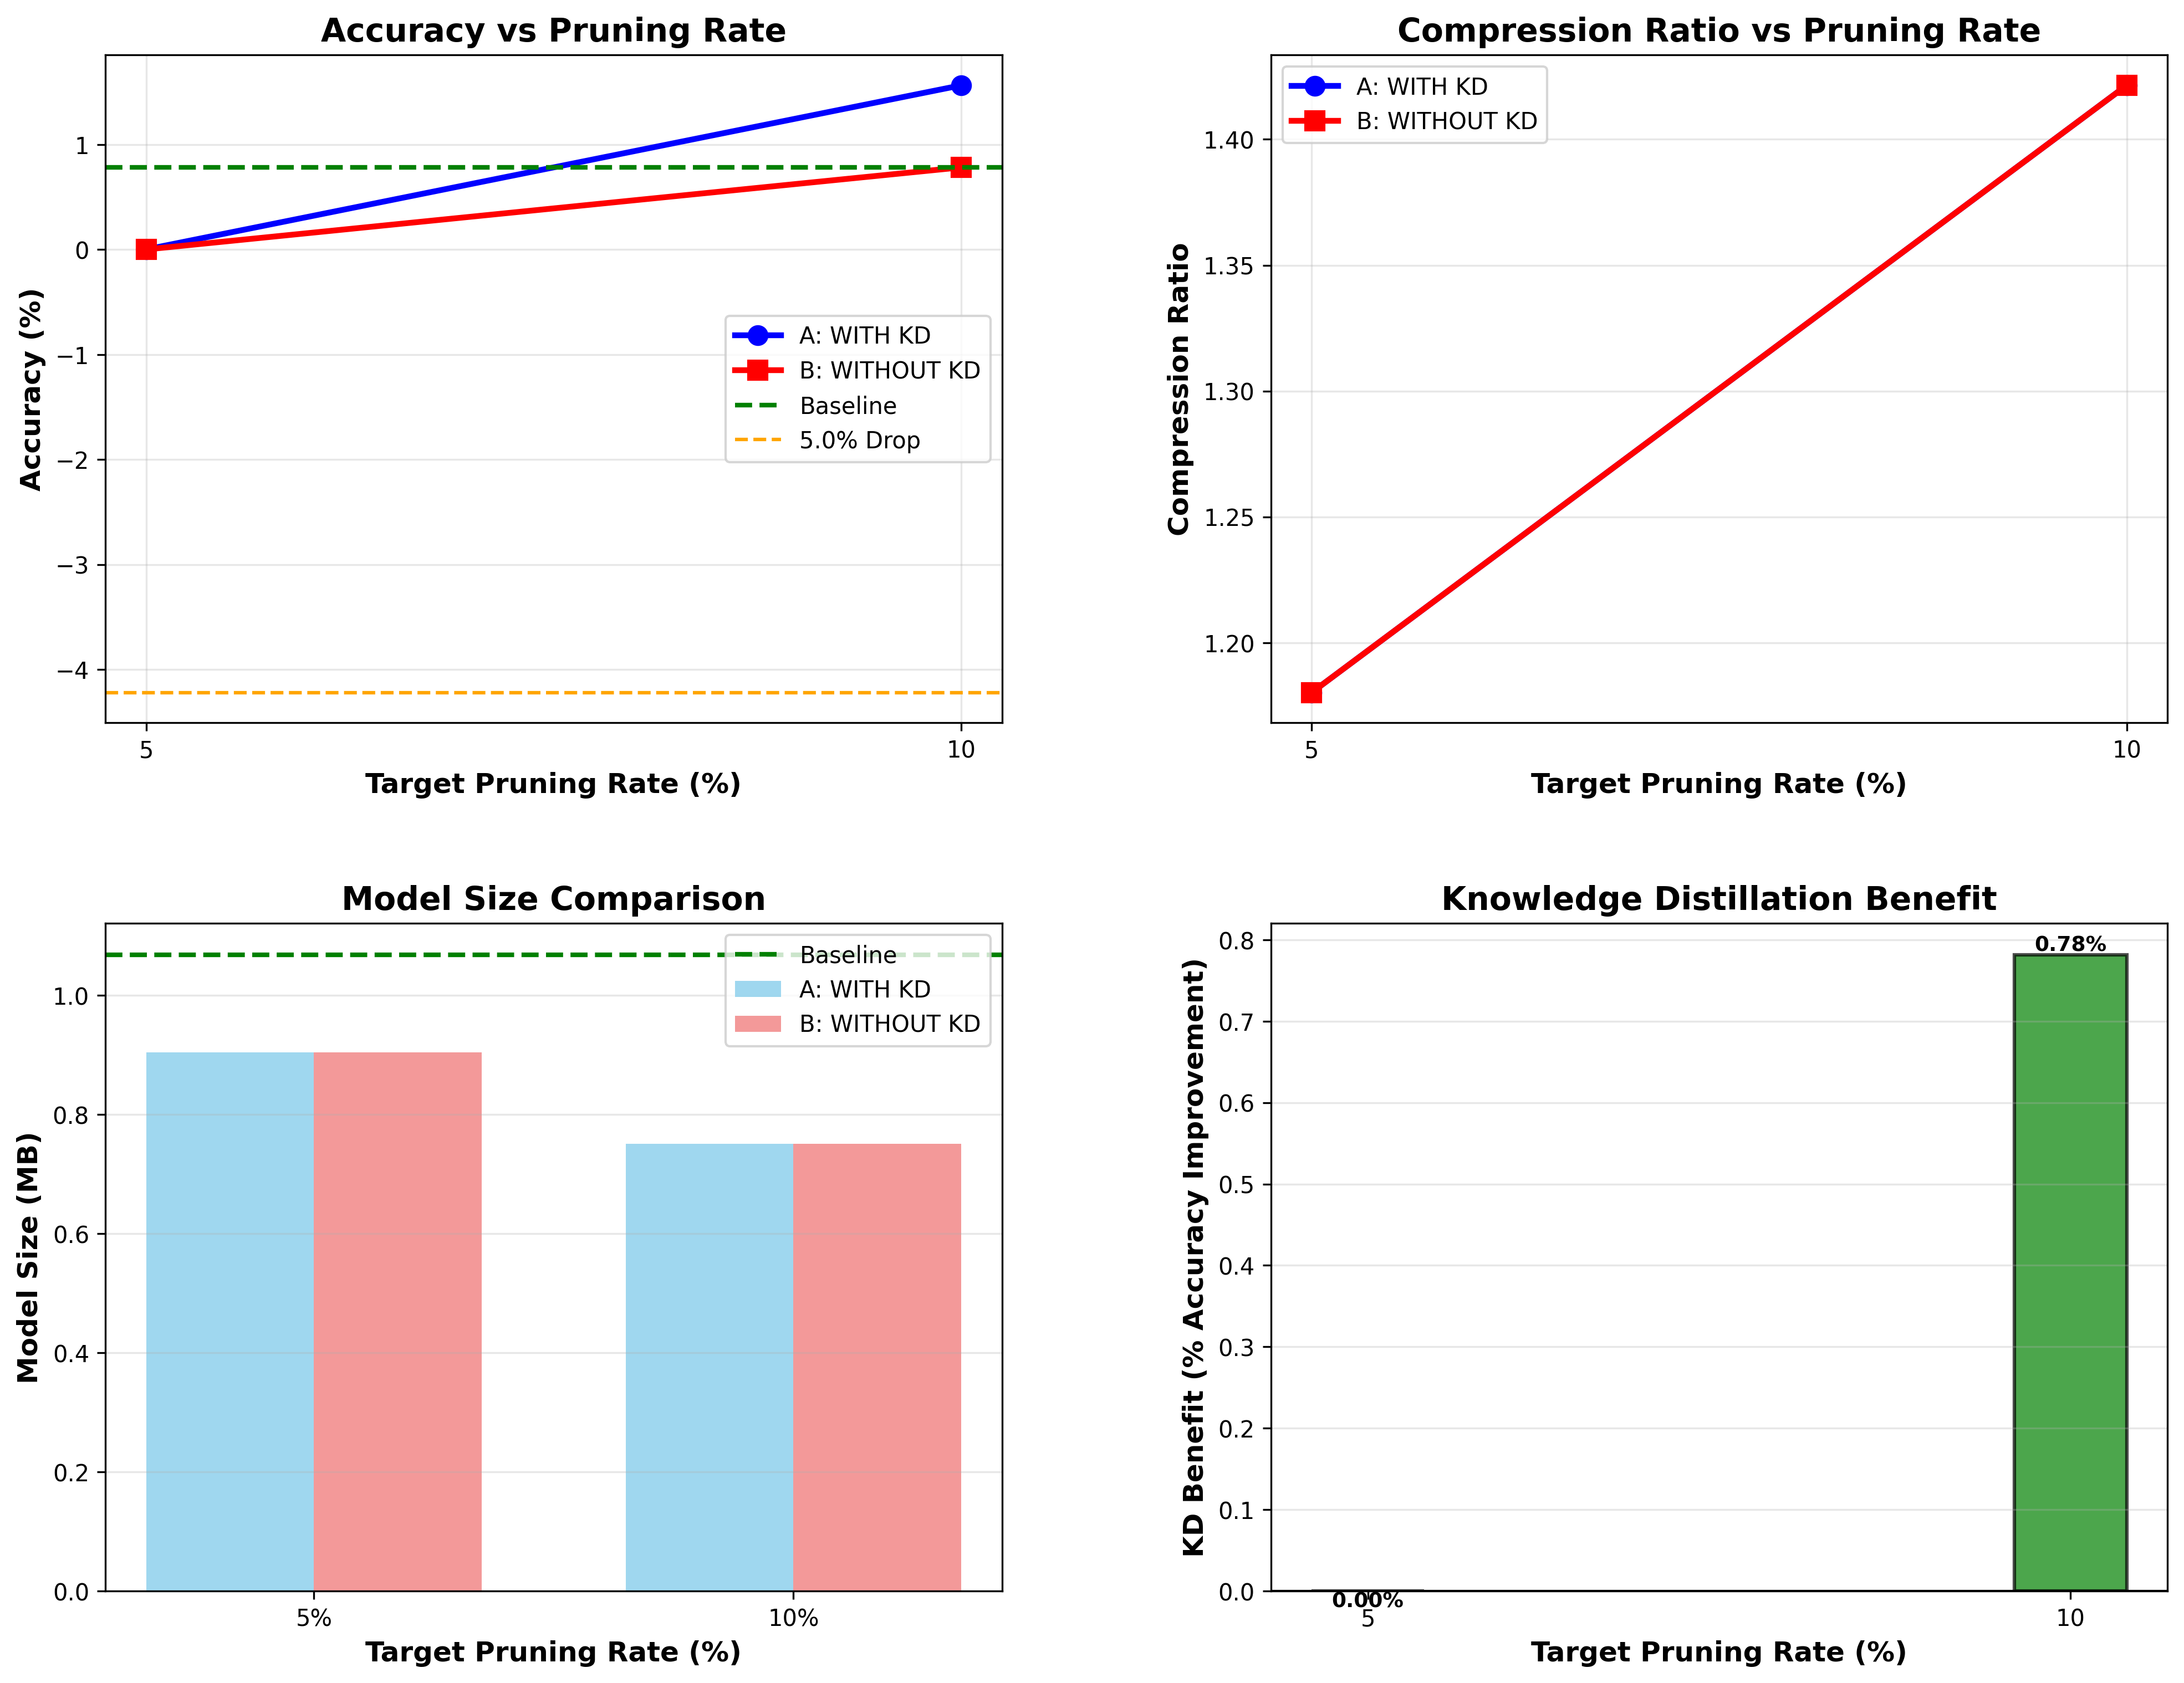

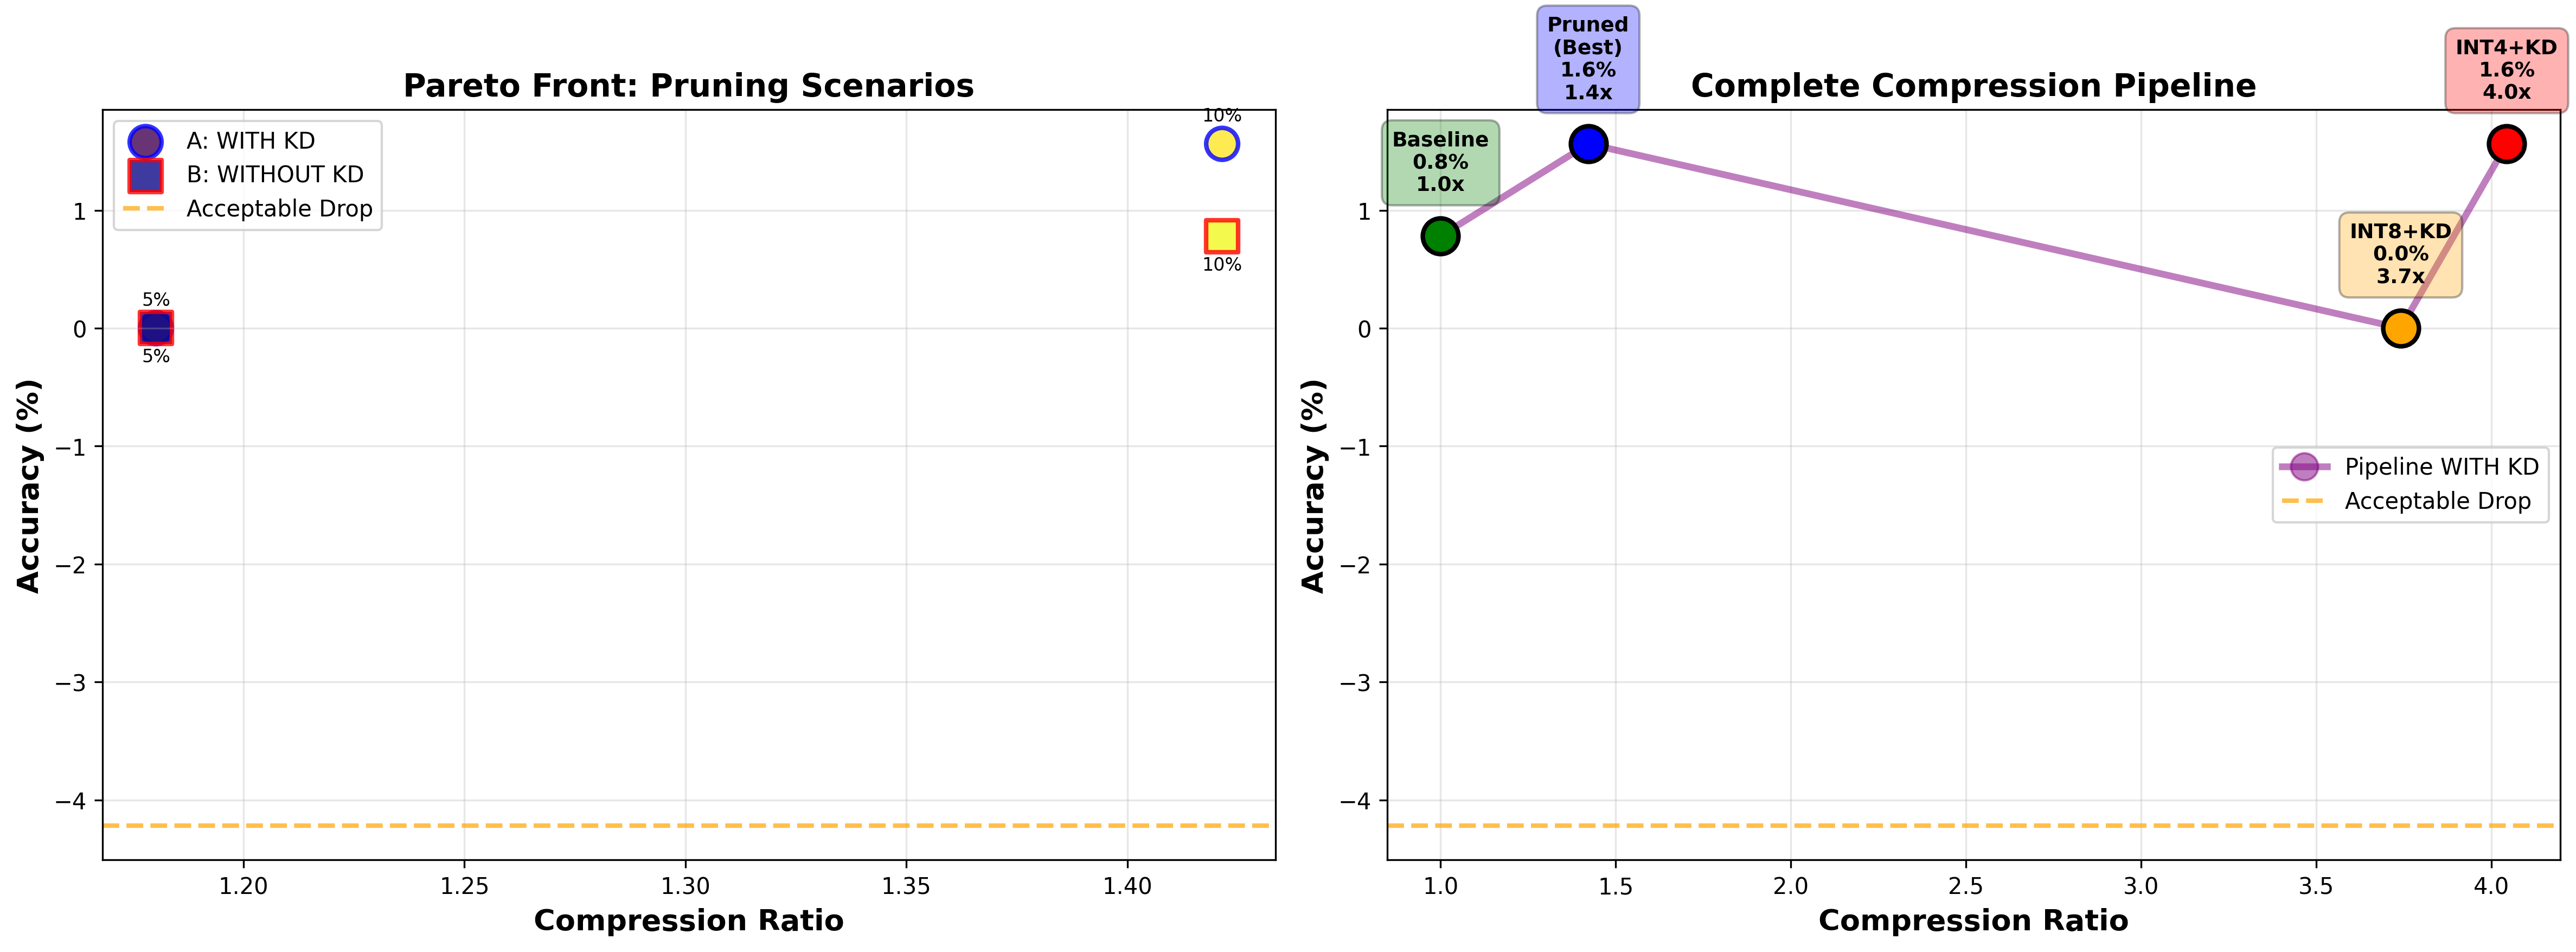

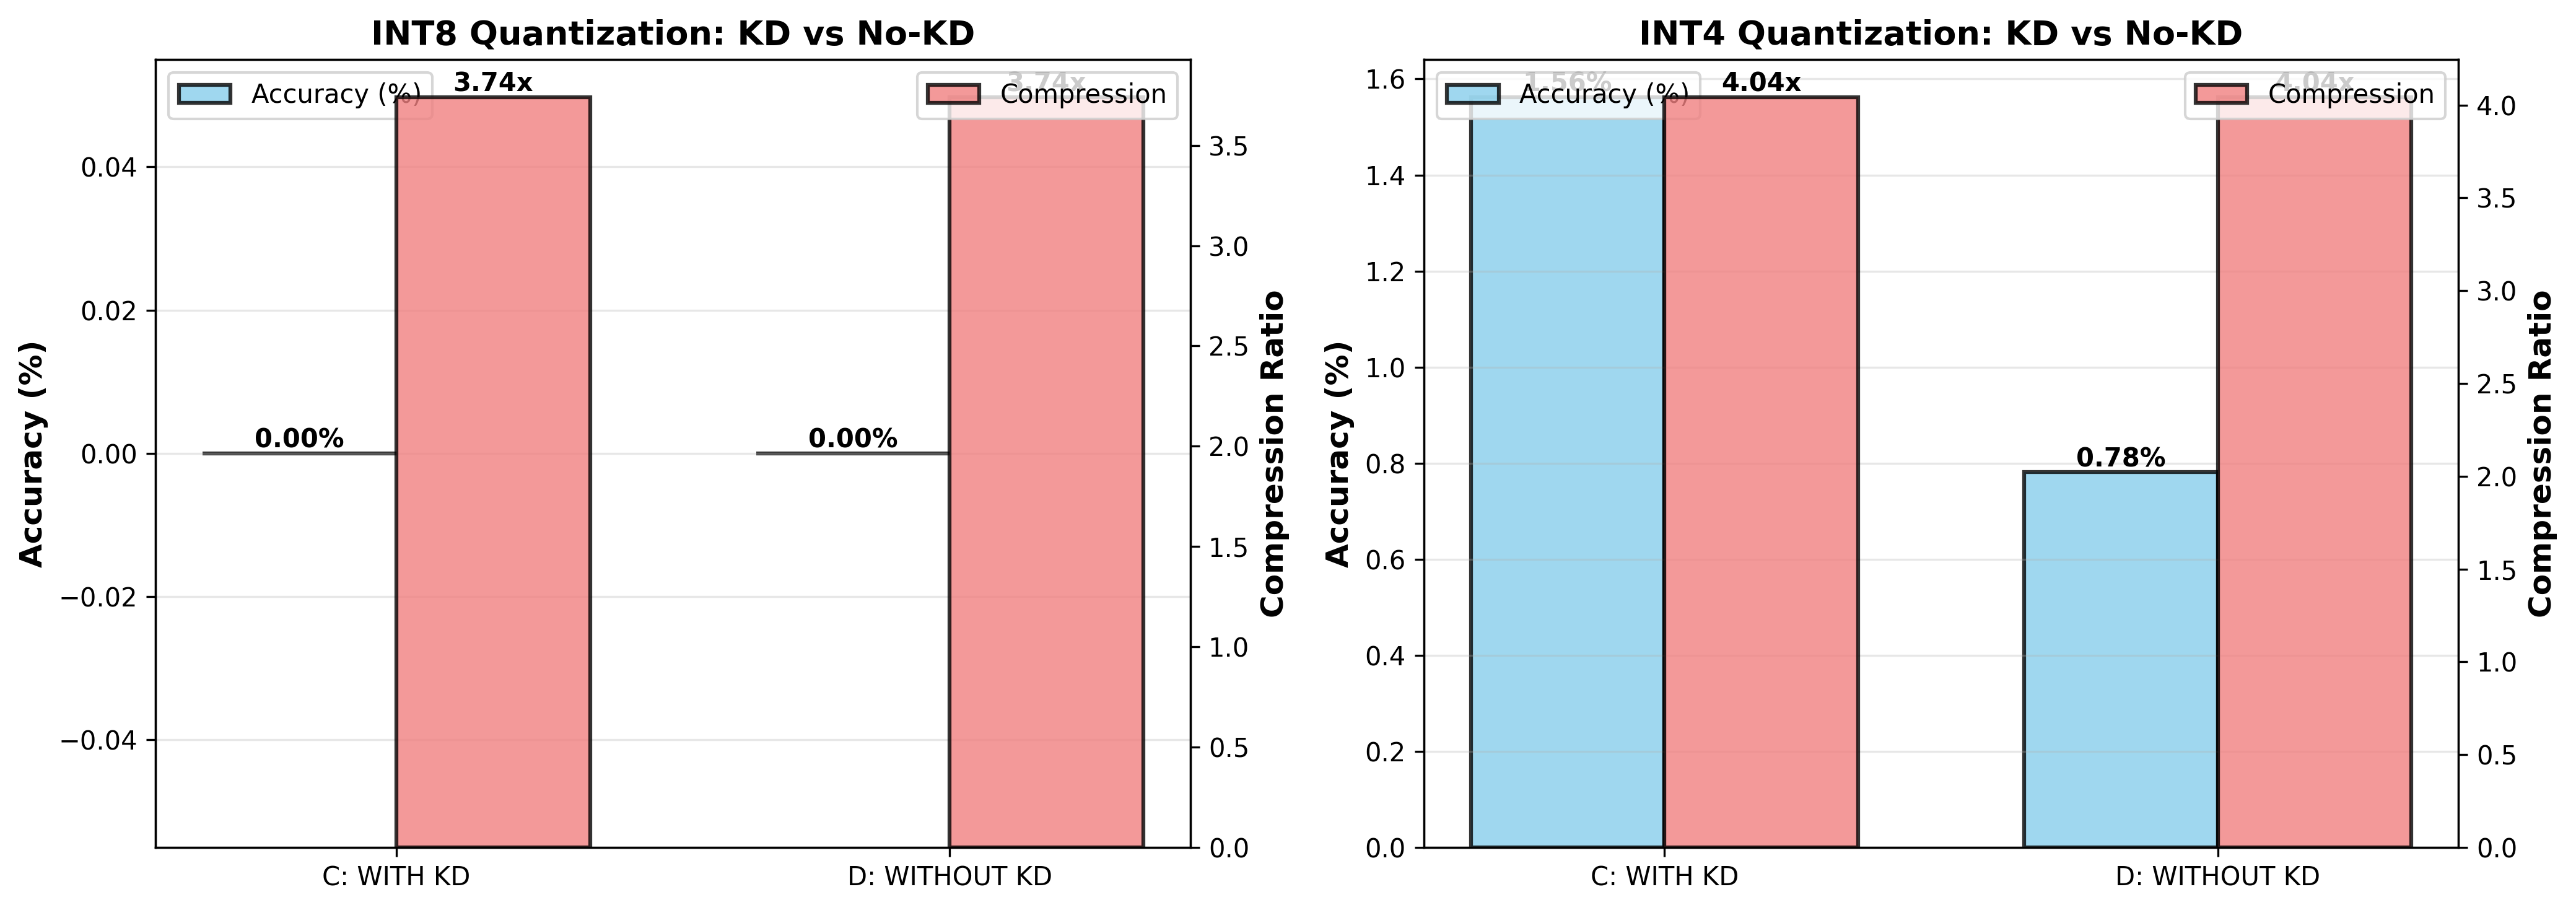

In [8]:
from IPython.display import Image, display

for name in ["plot1_pruning_comparison.png", "plot2_pareto_fronts.png", "plot3_qat_comparison.png"]:
    display(Image(filename=str(cfg.plots_dir / name)))

## Next steps

- Run a real (non-smoke-test) experiment with the CLI, e.g. from a terminal:

  ```bash
  resnet-compress --output-dir ./filter_pruning_experiment
  ```

  or, from a notebook cell, prefixed with `!`. Expect on the order of a day on a single
  GPU with the default schedule; pass `--pruning-rates`, `--initial-epochs`,
  `--finetune-epochs`, `--prune-iterations` and `--qat-epochs` to scale it down.
- Read [`NOTES.md`](../NOTES.md) for the two correctness bugs found in the original
  notebook and fixed in this package, plus other behavioral notes.
- See the module docstrings in `resnet_compression/pruning.py` and
  `resnet_compression/quantization.py` for the exact algorithms used.
